# BOLD Processing and Complex Graph Metrics Pipeline
### Schaefer 400 Parcellation & Yeo 7-Network System Mapping

This notebook implements a complete, end-to-end neuroimaging data processing and complex graph analysis pipeline for resting-state functional MRI (rs-fMRI). It is designed to take denoised BOLD time-series, perform network parcellation, construct high-dimensional functional connectivity matrices, compute complex topological network metrics across proportional threshold ranges, integrate them via Area Under the Curve (AUC) methods, and visualize them using a interactive 2D/3D dashboard.

---

### 🔬 Pipeline Architecture

```
   [Preprocessed & Denoised BOLD Images] 
                     │
                     ▼
     [Schaefer 400 Cortical Parcellation]
                     │
                     ▼
        [BOLD Time-Series Extraction]
                     │
                     ▼
  [Pearson Functional Connectivity Matrices]
                     │
                     ▼
    [Proportional Thresholding Range 0.2-0.5]
                     │
                     ▼
     [Graph Theory Metrics Calculation]
                     │
                     ▼
      [Area Under the Curve (AUC) ]
                     │
                     ▼
     [Demographic & Clinical Snychronization]
                     │
                     ▼
            [CSV Data Export]
                     │
                     ▼
    [Interactive 2D/3D Neuro-Dashboard]
```

In [ ]:
# Install requirements (if necessary)
%pip install nilearn nibabel dipy bctpy networkx numpy scipy pandas scikit-learn statsmodels matplotlib plotly ipywidgets

In [1]:
# Import libraries
import os
import numpy as np
import pandas as pd
import networkx as nx
import bct
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

from nilearn import datasets, plotting
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

In [2]:
# Define path and get subjects from the preprocessed BOLD signal
# NOTE: Using forward slashes to avoid SyntaxError with raw strings
path_subjects = './boldconn_extracted/'
subjects = [path_subjects + i for i in os.listdir(path_subjects) if i.endswith('.nii') or i.endswith('.nii.gz')]

names_subjects = []
demo_list = []
for i in os.listdir(path_subjects):
    if not (i.endswith('.nii') or i.endswith('.nii.gz')):
        continue
    subj = path_subjects + i
    parts = i.split("_")
    sub_id = parts[0]
    ses_id = parts[1].split("-")[1]
    name_subjects = f"{sub_id}_{ses_id}"
    names_subjects.append(name_subjects)
    demo_list.append({"Sujeto": name_subjects, "Grupo": ses_id})

df_demo = pd.DataFrame(demo_list)

print(f"Found {len(subjects)} subjects.")
print("First subjects:", names_subjects[:5])

Found 44 subjects.
First subjects: ['sub-00_post', 'sub-00_pre', 'sub-01_post', 'sub-01_pre', 'sub-11_post']


## 1. Cortical Parcellation & Yeo Network Mapping
This module loads the **Schaefer 400-ROI atlas** (at 1mm MNI resolution, 7-network parcellation) via the `nilearn` library. 
* **Yeo 7 Networks:** ROIs are classified into their respective functional networks: Visual (`Vis`), Somatomotor (`SomMot`), Dorsal Attention (`DorsAttn`), Ventral Attention (`VentAttn`), Limbic (`Limbic`), Frontoparietal (`Cont`), and Default Mode (`Default`).
* **Coordinate Extraction:** Extends mapping to retrieve MNI centroid coordinates for all 400 regions, vital for the downstream 3D brain representations.


In [3]:
# Load Schaefer atlas 400 ROIs and 7 networks
schaefer_atlas_400_7 = datasets.fetch_atlas_schaefer_2018(n_rois=400, yeo_networks=7, resolution_mm=1)

labels_sch_raw = [label for label in schaefer_atlas_400_7['labels'][1:]]

network_dict = defaultdict(list)

for label in labels_sch_raw:
    # If nilearn returns bytes instead of string, decode it
    if isinstance(label, bytes):
        label = label.decode('utf-8')
    parts = label.split('_')
    network_name = parts[2] 
    clean_label = label.replace("7Networks_", "")
    network_dict[network_name].append(clean_label)

print(f"Detected Schaefer Networks: {list(network_dict.keys())}")

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\victo\nilearn_data\schaefer_2018
Detected Schaefer Networks: ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']


## 2. BOLD Time-Series Extraction & Functional Connectivity Matrix Construction
In this module, the denoised BOLD functional volumes (`task-rest_desc-denoised_bold.nii.gz`) are processed. 
* **Signal Extraction:** Using `nilearn.maskers.NiftiLabelsMasker`, BOLD signals are extracted from the 400 parcellated regions of interest. 
* **Correlation Modeling:** Computes Pearson correlation coefficients ($r$) between all pairwise time-series, producing a $400 \times 400$ symmetric connectivity matrix for each subject and session (pre and post-treatment).



In [4]:
# Create the masker with Schaefer parcels
masker = NiftiLabelsMasker(
    labels_img=schaefer_atlas_400_7['maps'],
    standardize=True,
    verbose=1
)

subjects_schaefer_n7r400 = []

print("Extracting time series...")
for i, subject_path in enumerate(subjects):
    try:
        time_series = masker.fit_transform(subject_path)
        subjects_schaefer_n7r400.append(time_series)
        if (i+1) % 5 == 0:
            print(f"... Processed {i+1} subjects")
    except Exception as e:
        print(f"Error processing subject index {i}: {e}")

subjects_schaefer_n7r400_array = np.array(subjects_schaefer_n7r400)
print(f"Final shape of time series: {subjects_schaefer_n7r400_array.shape} (subjects, time, ROIs)")

Extracting time series...
[NiftiLabelsMasker.wrapped] Loading regions from 'C:\\Users\\victo\\nilearn_data\\schaefer_2018\\Schaefer2018_400Parcels_7Networks_order_FSLMNI152_1mm.nii.gz'
[NiftiLabelsMasker.wrapped] Resampling regions
[NiftiLabelsMasker.wrapped] Finished fit
[NiftiLabelsMasker.wrapped] Loading data from 'C:/Users/victo/Documentos/Proyecto Investigacion/boldconn_extracted/sub-00_ses-post_task-rest_desc-denoised_bold.nii.gz'
[NiftiLabelsMasker.wrapped] Extracting region signals
[NiftiLabelsMasker.wrapped] Cleaning extracted signals
[NiftiLabelsMasker.wrapped] Loading regions from 'C:\\Users\\victo\\nilearn_data\\schaefer_2018\\Schaefer2018_400Parcels_7Networks_order_FSLMNI152_1mm.nii.gz'
[NiftiLabelsMasker.wrapped] Resampling regions
[NiftiLabelsMasker.wrapped] Finished fit
[NiftiLabelsMasker.wrapped] Loading data from 'C:/Users/victo/Documentos/Proyecto Investigacion/boldconn_extracted/sub-00_ses-pre_task-rest_desc-denoised_bold.nii.gz'
[NiftiLabelsMasker.wrapped] Extracti

In [5]:
print("Calculating complete Pearson connectivity matrices...")
# ConnectivityMeasure is used to obtain the Pearson connectivity between all ROIs simultaneously
pearson_correlation_matrices = ConnectivityMeasure(kind='correlation')
subjects_matrix_pearson = pearson_correlation_matrices.fit_transform(subjects_schaefer_n7r400_array)

print(f"Shape of resulting Pearson matrices: {subjects_matrix_pearson.shape}")

Calculating complete Pearson connectivity matrices...
Shape of resulting Pearson matrices: (44, 400, 400)


## 3. Functional Connectivity Visualization
Heatmap representations of the $400 \times 400$ Pearson correlation matrices. This allows rapid visual inspection of functional coupling strength within and between the Yeo 7 networks, facilitating the identification of hyper- or hypo-connectivity patterns.


Plotting connectivity matrix for subject: sub-00_post


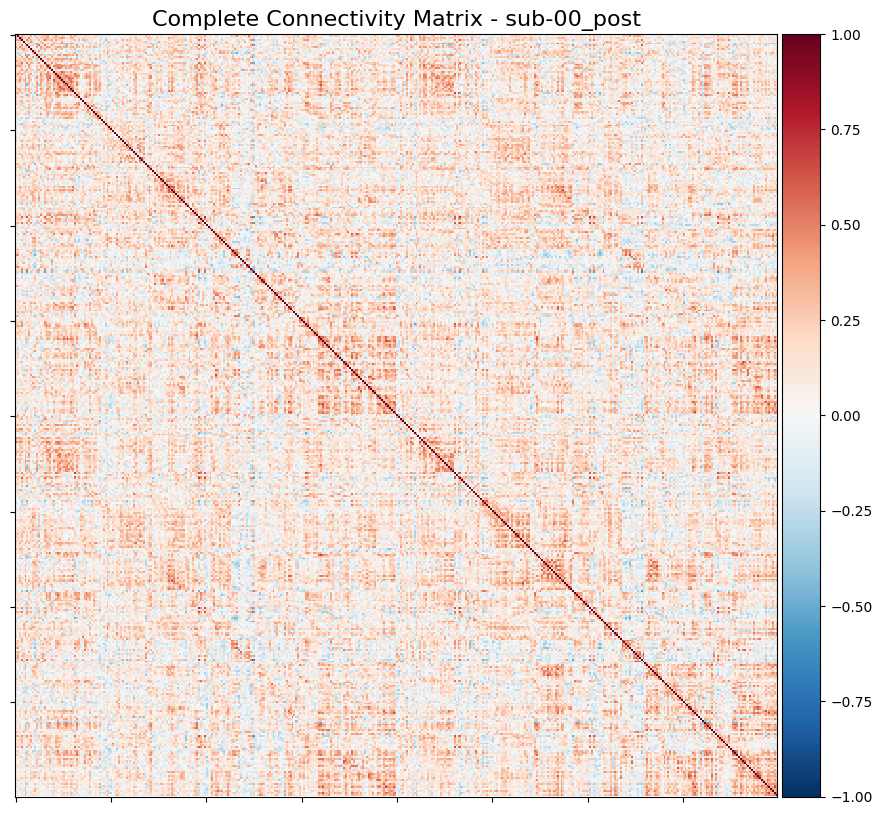

In [6]:
# Plot the connectivity matrix for the first subject as an example
if len(subjects_matrix_pearson) > 0:
    print(f"Plotting connectivity matrix for subject: {names_subjects[0]}")
    plotting.plot_matrix(
        subjects_matrix_pearson[0],
        figure=(10, 8),
        title=f"Complete Connectivity Matrix - {names_subjects[0]}",
        vmax=1.0, vmin=-1.0,
        colorbar=True
    )
    plotting.show()
else:
    print("No matrices available to plot.")

## 4. Complex Graph Theory Metrics Computation (Density Thresholding)
To convert continuous correlation matrices into sparse brain graphs, we apply **proportional thresholding**. Instead of analyzing a single arbitrary threshold, we calculate topological network metrics over a density range of $0.2$ to $0.5$ (with steps of $0.01$). 
### 📐 Mathematical Definitions of Brain Network Metrics

#### A. Global Network Topology (Wholistic Integration & Segregation)
1. **Average Degree:** The average number of functional connections per brain region.
2. **Average Clustering Coefficient:** Measures localized segregation, indicating how interconnected a node's neighbors are.
3. **Global Efficiency:** Quantifies the network's capacity for parallel information transfer across long distances (integration).
4. **Assortativity:** Measures the tendency of high-degree brain nodes to connect to other high-degree nodes.
5. **Modularity (Louvain Algorithm):** Quantifies the degree to which the brain graph can be partitioned into distinct communities or modules.

#### B. Nodal/Local Network Topology (Regional Centrality & Influence)
1. **Node Degree:** Total count of functional connections a specific brain region has.
2. **Nodal Clustering:** Interconnectedness of the immediate neighborhood of a specific node.
3. **Local Efficiency:** Capacity of a sub-graph to share information if the focal node is removed.
4. **Betweenness Centrality:** Proportion of all shortest paths passing through a given node, indicating its role as a network hub.
5. **Louvain Community Belonging:** Dynamic identification of localized module memberships.


In [7]:
# Network Classification
primary_keywords = ['Vis', 'SomMot'] 
associative_keywords = ['DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default', 'TempPar']

def get_network_type(name):
    """Determines if the network name is Primary or Associative."""    
    for key in associative_keywords:
        if key in name: return 'Associative'
    for key in primary_keywords:
        if key in name: return 'Primary'
    return 'Other'

In [9]:
# Búsqueda del umbral mínimo de conexión para cada sujeto
print("Calculando umbral mínimo de conexión por sujeto...")
min_thresholds = []

for i, subject_id in enumerate(names_subjects):
    matrix = subjects_matrix_pearson[i]
    abs_matrix = np.abs(matrix)
    
    connected_threshold = None
    # Iteramos desde densidad 0.01 hasta 1.0. 
    # Mayor densidad = más aristas retenidas = más probable que esté conectada.
    test_densities = np.arange(0.01, 1.01, 0.01)
    for d in test_densities:
        W_thr = bct.threshold_proportional(abs_matrix, d)
        A_bin = bct.weight_conversion(W_thr, 'binarize')
        
        G = nx.from_numpy_array(A_bin)
        if nx.is_connected(G):
            connected_threshold = round(d, 2)
            break
            
    min_thresholds.append({'Sujeto': subject_id, 'Umbral_Minimo': connected_threshold})

df_min_thresholds = pd.DataFrame(min_thresholds)
display(df_min_thresholds.head())

Calculando umbral mínimo de conexión por sujeto...


,Sujeto,Umbral_Minimo
0,sub-00_post,0.09
1,sub-00_pre,0.12
2,sub-01_post,0.18
3,sub-01_pre,0.14
4,sub-11_post,0.14


In [8]:
def calculate_general_metrics(matrix, density, subject_id, network_dict): 
    # Absolute values of the complete functional matrix
    abs_matrix = np.abs(matrix)
    
    # Determine the proportional threshold for the given density and binarize the matrix
    W_thr = bct.threshold_proportional(abs_matrix, density)
    A_bin = bct.weight_conversion(W_thr, 'binarize')
    
    # Node to Network mapping
    node_to_network = {node: net for net, nodes in network_dict.items() for node in nodes}

    # List of names in order corresponding to the extracted Schaefer matrix
    ordered_names = []
    for net in network_dict:
        ordered_names.extend(network_dict[net])
        
    # If the matrix is strictly Schaefer 400
    if len(ordered_names) != matrix.shape[0]:
        # Reprogram to extract exactly 400 from labels_sch_raw by its original order
        ordered_names = [l.decode('utf-8').replace("7Networks_", "") if isinstance(l, bytes) else l.replace("7Networks_", "") for l in labels_sch_raw]

    rows_list = []

    try:
        # ----- GLOBAL METRICS ------

        geff_global = bct.efficiency_bin(A_bin)
        assortativity = bct.assortativity_bin(A_bin)
        ci, Q_louvain = bct.community_louvain(A_bin, gamma=1)
        
        global_metrics = {
            'AvgDegree': np.mean(bct.degrees_und(A_bin)),
            'AvgClustering': np.mean(bct.clustering_coef_bu(A_bin)),
            'Efficiency': geff_global,
            'Assortativity': assortativity,
            
            'Modularity': Q_louvain
        }
        
        for metric_name, metric_val in global_metrics.items():
            rows_list.append({
                'Sujeto': subject_id,
                'Umbral': density,
                'Tipo_Red': 'Completa', 
                'Red': 'General',
                'Clasificacion_Red': 'All',
                'Tipo_Metrica': 'Global', 
                'Nodo': 'Todos',
                'Metrica': metric_name, 
                'Valor': metric_val,
            })
        
        # ---- NODAL METRICS ------
        degree_local = bct.degrees_und(A_bin)
        clustering_local = bct.clustering_coef_bu(A_bin)
        geff_local = bct.efficiency_bin(A_bin, local=True)
        betweenness_bin = bct.betweenness_bin(A_bin) 
              
        for i, node_name in enumerate(ordered_names):
            belonging_network = node_to_network.get(node_name, "Desconocida")
            node_specific_type = get_network_type(node_name)
            
            nodal_metrics = {
                'Degree': degree_local[i],
                'Clustering': clustering_local[i],
                'Efficiency_Local': geff_local[i],
                'Betweenness': betweenness_bin[i],                
                'Q_Louvain': ci[i]
                
            }
            
            for metric_name, metric_val in nodal_metrics.items():
                rows_list.append({
                    'Sujeto': subject_id,
                    'Umbral': density, 
                    'Tipo_Red': 'Completa', 
                    'Red': belonging_network, 
                    'Clasificacion_Red': node_specific_type,                     
                    'Tipo_Metrica': 'Nodal', 
                    'Nodo': node_name,
                    'Metrica': metric_name, 
                    'Valor': metric_val,
                })                 
    except Exception as e:
        print(f"❌ Error calculating metrics for {subject_id}: {e}")
        
    return rows_list

In [10]:
# Setup thresholds
min_t, max_t, step = 0.2, 0.5, 0.01
thresholds = np.round(np.arange(min_t, max_t + (step/2), step), 10).tolist()
final_data = []

print("Calculating nodal and global metrics for all thresholds...")

# Iterate through each subject's matrix
for i, subject_id in enumerate(names_subjects):
    matrix = subjects_matrix_pearson[i]
    
    # Calculate metrics for each threshold
    for t in thresholds:
        res_rows = calculate_general_metrics(matrix, t, subject_id, network_dict)
        final_data.extend(res_rows)
        
print(f"Calculation finished! Total generated records: {len(final_data)}")

Calculating nodal and global metrics for all thresholds...
Calculation finished! Total generated records: 2734820


## 5. Threshold-Independent Integration via Area Under the Curve (AUC)
In network neuroscience, choosing a single arbitrary threshold can drastically bias topological comparisons. To bypass this, we compute the **Area Under the Curve (AUC)** across the entire proportional threshold range ($0.2$ to $0.5$) using the trapezoidal rule:

$$AUC = \int_{D_{min}}^{D_{max}} f(D) \, dD$$

This integrates topological values to yield a single robust metric per node and subject that represents stable, threshold-independent connectivity patterns.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import auc

# 1. Convertimos la lista de resultados (final_data) a un DataFrame
df_results = pd.DataFrame(final_data)

# Aseguramos el orden de las columnas (manteniendo las tuyas en español)
columnas = ['Sujeto', 'Umbral', 'Tipo_Red', 'Red', 'Clasificacion_Red', 'Tipo_Metrica', 'Nodo', 'Metrica', 'Valor']
# Filtramos solo las columnas que existan por seguridad
columnas_presentes = [col for col in columnas if col in df_results.columns]
df_results = df_results[columnas_presentes]

print(f"Calculando AUC para las métricas a través de los umbrales (0.2 a 0.5)...")

# 2. Orden vital: Para que la regla del trapecio (la matemática detrás de 'auc') funcione, 
# la variable independiente (Umbral) DEBE estar ordenada de menor a mayor de forma estricta.
df_all = df_results.sort_values(by=['Sujeto', 'Nodo', 'Metrica', 'Umbral'])

# 3. Definimos la función de integración
def calculate_auc(group):
    # Validamos que haya suficientes puntos en el rango [0.2 - 0.5] para trazar el área
    if len(group) > 1:
        return auc(group['Umbral'], group['Valor'])
    return np.nan # np.nan maneja mejor los datos faltantes en Pandas que 'None'

# 4. Agrupamos por todas las características topológicas y de sujeto, dejando fuera Umbral y Valor
cols_group = ['Sujeto', 'Tipo_Red', 'Red', 'Clasificacion_Red', 'Tipo_Metrica', 'Nodo', 'Metrica']
cols_group_presentes = [col for col in cols_group if col in df_all.columns]

# 5. Aplicamos el cálculo
df_auc_all = df_all.groupby(cols_group_presentes).apply(calculate_auc).reset_index(name='AUC')

print(f"Cálculo finalizado. Total de registros AUC consolidados: {len(df_auc_all)}")
display(df_auc_all.head())

## 6. Functional Network-Level AUC Profiling
Extracts and groups AUC results specifically for localized functional networks (such as the Somatomotor Network `SomMot` and other subsystems). This focuses the statistical comparison onto distinct functional modules, enabling targeted resting-state network profiling.


In [24]:
# Extraer resultados solo para la red somatomotora 'SomMot'
df_results = pd.DataFrame(final_data)
    # Output columns names are kept in Spanish for consistency with the rest of your project data tables
columnas = ['Sujeto', 'Umbral', 'Tipo_Red', 'Red', 'Clasificacion_Red', 'Tipo_Metrica', 'Nodo', 'Metrica', 'Valor']
df_results = df_results[columnas]
if 'df_results' in locals():
    df_sommot = df_results[df_results['Red'].isin(['SomMot', 'General'])].copy()
    print(f"Total de registros extraídos para la red SomMot: {len(df_sommot)}")
else:
    print("Por favor, asegúrate de haber ejecutado la celda anterior que crea df_results.")

Total de registros extraídos para la red SomMot: 531960


In [25]:
from sklearn.metrics import auc

print("Calculando AUC para las métricas a través de múltiples umbrales (Red SomMot)...")

# Ordenamos por sujeto, nodo, métrica y finalmente por UMBRAL (vital para la curva AUC)
df_sommot = df_sommot.sort_values(by=['Sujeto', 'Nodo', 'Metrica', 'Umbral'])

def calculate_auc(group):
    # Validamos que haya más de un punto para calcular AUC
    if len(group) > 1:
        return auc(group['Umbral'], group['Valor'])
    return None

# Agrupamos todo excepto el Umbral y el Valor
cols_group = ['Sujeto', 'Tipo_Red', 'Red', 'Clasificacion_Red', 'Tipo_Metrica', 'Nodo', 'Metrica']
df_auc_sommot = df_sommot.groupby(cols_group).apply(calculate_auc).reset_index(name='AUC')

display(df_auc_sommot.head())

Calculando AUC para las métricas a través de múltiples umbrales (Red SomMot)...


,Sujeto,Tipo_Red,Red,Clasificacion_Red,Tipo_Metrica,Nodo,Metrica,AUC
0,sub-00_post,Completa,General,All,Global,Todos,Assortativity,0.034912
1,sub-00_post,Completa,General,All,Global,Todos,AvgClustering,0.141459
2,sub-00_post,Completa,General,All,Global,Todos,AvgDegree,41.895000
3,sub-00_post,Completa,General,All,Global,Todos,Efficiency,0.202470
4,sub-00_post,Completa,General,All,Global,Todos,Modularity,0.050665


## 7. CSV Data Export 
Saves all calculated data, standardized CSV files. 
* `resultados_metricas_por_umbral.csv`: Raw metrics across all steps of density thresholds.
* `resultados_auc_todas_las_redes.csv`: Compact, threshold-independent integrated AUC values.
* `umbrales_minimos.csv`: Subject-level minimum connection density to maintain a connected graph.
* `demograficos.csv`: Clinical profiles and group designations (pre vs. post-treatment).


In [20]:
# --- GUARDAR DATOS ORIGINALES (TODOS LOS UMBRALES) ---
# Este archivo contiene los resultados de cada métrica para cada umbral (0.2, 0.21, ..., 0.5)
nombre_archivo_original = 'resultados_metricas_por_umbral.csv'

df_results.to_csv(nombre_archivo_original, 
                  index=False, 
                  encoding='utf-8-sig', 
                  sep=',')

print(f"Archivo guardado: {nombre_archivo_original} ({len(df_results)} filas)")


# --- GUARDAR RESULTADOS AUC (TODAS LAS REDES) ---
# Este archivo es el resumen final: un único valor de AUC por cada métrica/nodo/sujeto
nombre_archivo_auc = 'resultados_auc_todas_las_redes.csv'

df_auc_all.to_csv(nombre_archivo_auc, 
                  index=False, 
                  encoding='utf-8-sig', 
                  sep=',')

print(f"Archivo guardado: {nombre_archivo_auc} ({len(df_auc_all)} filas)")

df_umbrales = pd.DataFrame(df_min_thresholds).T.reset_index().rename(columns={'index': 'Sujeto'})
df_umbrales.to_csv('umbrales_minimos.csv', index=False)
df_demo.to_csv('demograficos.csv', index=False)
df_min_thresholds.to_csv('umbrales_minimos.csv', index=False)
    df_demo.to_csv('demograficos.csv', index=False)
    print("\n¡Proceso de exportación completado con éxito!")

Archivo guardado: resultados_metricas_por_umbral.csv (2734820 filas)
Archivo guardado: resultados_auc_todas_las_redes.csv (88220 filas)

¡Proceso de exportación completado con éxito!


## 8. Interactive Neuro-Dashboard & 3D Brain Network

### 🎛️ Interactive Filters and Features
* **Graph Selector (`dropdown_plot_type`):** Switch between four analytical plot views:
  1. *Minimum Connection Density Thresholds* (Boxplots comparing pre vs. post sessions).
  2. *AUC Boxplots* (Statistical distributions of integrated topological metrics).
  3. *Metric-Density Threshold Curves* (Visualizing metric progression across the range $0.2 \le D \le 0.5$).
  4. *Interactive 3D Glass Brain Network* (Real-time MNI spatial plotting).
* **Dynamic Network Selector (`dropdown_red`):** Filter boxplots and curves dynamically by selecting specific Yeo networks (e.g., `SomMot`, `Default`, `Visual`) or view the whole brain (`General`).
* **Subject Exclusion Panel (`select_sujetos`):** A custom scrollable checkbox container allowing researchers to exclude specific outlier subjects on-the-fly, instantly updating all graphs.
* **3D Glass Brain Visualization (`plot_3d_brain`):** Interactive 3D plotting overlaying functional nodes and connections (at a custom Pearson threshold $r$) onto the 3D cortical surfaces (`fsaverage5` pial meshes).


In [18]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from nilearn import datasets, plotting
from nilearn.surface import load_surf_mesh
import os
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

print("Calculando coordenadas 3D, matrices promedio y cargando atlas cortical...")

# 1. Cargar Datos Demográficos Correctamente
print('Usando df_demo generado a partir de los nombres de los archivos.')
    # Mapear 0 y 1 a Control y Portador


# 2. Extraer coordenadas MNI del atlas Schaefer
coords = plotting.find_parcellation_cut_coords(schaefer_atlas_400_7.maps)
sommot_nodes = network_dict.get('SomMot', [])
sommot_coords = []
sommot_indices = []

for i, label in enumerate(labels_sch_raw):
    clean_label = label.replace("7Networks_", "")
    if clean_label in sommot_nodes:
        sommot_coords.append(coords[i])
        sommot_indices.append(i)

sommot_coords = np.array(sommot_coords)

# 3. Cargar datos de superficie para el Glass Brain (fsaverage5)
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
coords_left, faces_left = load_surf_mesh(fsaverage.pial_left)
coords_right, faces_right = load_surf_mesh(fsaverage.pial_right)

# 4. Integrar dataframes usando los CSV exportados
try:
    df_demo_csv = pd.read_csv('demograficos.csv')
    df_all_results = pd.read_csv('resultados_metricas_por_umbral.csv')
    df_auc_all_csv = pd.read_csv('resultados_auc_todas_las_redes.csv')
    df_umbrales_csv = pd.read_csv('umbrales_minimos.csv')
    
    # El archivo umbrales_minimos.csv contiene [Sujeto, Umbral_Minimo] de la red completa directamente.
    # No requiere melt.
    df_min_thresholds_plot = df_umbrales_csv.merge(df_demo_csv[['Sujeto', 'Grupo']], on='Sujeto', how='left')
    
    # Combinar los demográficos
    df_results_plot = df_all_results.merge(df_demo_csv[['Sujeto', 'Grupo']], on='Sujeto', how='left')
    df_auc_plot = df_auc_all_csv.merge(df_demo_csv[['Sujeto', 'Grupo']], on='Sujeto', how='left')
    
    # Crear la lista de sujetos excluidos posibles para el widget
    todos_los_sujetos = df_demo_csv['Sujeto'].tolist()
    
    print("Datos cargados correctamente desde los archivos CSV (Modo Portátil).")
except FileNotFoundError as e:
    print(f"No se encontraron los archivos CSV ({e}). Se usarán las variables en memoria.")
    # Fallback si no están los CSV
    if 'df_results' in locals():
        df_results_plot = df_results.merge(df_demo[['Sujeto', 'Grupo']], on='Sujeto', how='left')
    if 'df_auc_all' in locals():
        df_auc_plot = df_auc_all.merge(df_demo[['Sujeto', 'Grupo']], on='Sujeto', how='left')
    if 'df_min_thresholds' in locals():
        df_min_thresholds_plot = df_min_thresholds.merge(df_demo[['Sujeto', 'Grupo']], on='Sujeto', how='left')
    todos_los_sujetos = df_demo['Sujeto'].tolist() if not df_demo.empty else []

# 5. Calcular matrices promedio para SomMot
matrix_sommot_list = []
for matrix in subjects_matrix_pearson:
    sub_matrix = matrix[np.ix_(sommot_indices, sommot_indices)]
    matrix_sommot_list.append(sub_matrix)

matrix_sommot_array = np.array(matrix_sommot_list)
avg_matrix_global = np.mean(matrix_sommot_array, axis=0)

if not df_demo.empty:
    idx_pre = [i for i, subj in enumerate(names_subjects) if not df_demo[df_demo['Sujeto'] == subj].empty and df_demo[df_demo['Sujeto'] == subj]['Grupo'].values[0] == 'pre']
    idx_post = [i for i, subj in enumerate(names_subjects) if not df_demo[df_demo['Sujeto'] == subj].empty and df_demo[df_demo['Sujeto'] == subj]['Grupo'].values[0] == 'post']
    
    avg_matrix_pre = np.mean(matrix_sommot_array[idx_pre], axis=0) if idx_pre else avg_matrix_global
    avg_matrix_post = np.mean(matrix_sommot_array[idx_post], axis=0) if idx_post else avg_matrix_global
else:
    avg_matrix_pre = avg_matrix_global
    avg_matrix_post = avg_matrix_global

matrices_dict = {
    'Global': avg_matrix_global,
    'pre': avg_matrix_pre,
    'post': avg_matrix_post
}
print(f"Listos {len(sommot_nodes)} nodos para la visualización 3D.")

Calculando coordenadas 3D, matrices promedio y cargando atlas cortical...
Usando df_demo generado a partir de los nombres de los archivos.
Datos cargados correctamente desde los archivos CSV (Modo Portátil).
Listos 77 nodos para la visualización 3D.


In [19]:
def plot_3d_brain(matrix_type='Global', threshold=0.5, red_name='SomMot'):
    # Verificar que las variables globales necesarias existan
    required_globals = ['matrices_dict', 'sommot_coords', 'sommot_nodes', 'coords_left', 'faces_left', 'coords_right', 'faces_right']
    missing = [var for var in required_globals if var not in globals()]
    if missing:
        print("No se puede renderizar la Red 3D en modo portátil sin las variables en memoria.")
        print("Para usar esta visualización, debes haber ejecutado las celdas del pipeline completo de este notebook")
        print("para cargar las mallas 3D y calcular las matrices de conectividad promedio.")
        return

    # Si se selecciona otra red, avisar al usuario que está optimizado para SomMot
    if red_name != 'SomMot':
        print(f"Nota: La visualización 3D está configurada específicamente para la red 'SomMot'.")
        print(f"Mostrando la red 'SomMot' para el grupo '{matrix_type}'...")
        
    matrix = matrices_dict.get(matrix_type, None)
    if matrix is None:
        print(f"Error: No se encontró la matriz para el tipo '{matrix_type}'.")
        return
        
    x_nodes, y_nodes, z_nodes = sommot_coords[:, 0], sommot_coords[:, 1], sommot_coords[:, 2]
    
    # Trace 1: Nodos
    trace_nodes = go.Scatter3d(
        x=x_nodes, y=y_nodes, z=z_nodes,
        mode='markers',
        marker=dict(size=6, color='dodgerblue', line=dict(color='black', width=1)),
        text=sommot_nodes, hoverinfo='text', name='Nodos SomMot'
    )
    
    # Trace 2: Conexiones
    edge_x, edge_y, edge_z = [], [], []
    for i in range(len(sommot_nodes)):
        for j in range(i+1, len(sommot_nodes)):
            if matrix[i, j] > threshold:
                edge_x.extend([x_nodes[i], x_nodes[j], None])
                edge_y.extend([y_nodes[i], y_nodes[j], None])
                edge_z.extend([z_nodes[i], z_nodes[j], None])
                
    trace_edges = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        mode='lines', line=dict(color='red', width=2),
        hoverinfo='none', name=f'Conexiones (r > {threshold})'
    )
    
    # Traces 3 y 4: Glass Brain (Mallas izquierda y derecha)
    trace_mesh_left = go.Mesh3d(
        x=coords_left[:, 0], y=coords_left[:, 1], z=coords_left[:, 2],
        i=faces_left[:, 0], j=faces_left[:, 1], k=faces_left[:, 2],
        color='lightgray', opacity=0.15, hoverinfo='none', showscale=False, name='Cerebro Izq'
    )
    
    trace_mesh_right = go.Mesh3d(
        x=coords_right[:, 0], y=coords_right[:, 1], z=coords_right[:, 2],
        i=faces_right[:, 0], j=faces_right[:, 1], k=faces_right[:, 2],
        color='lightgray', opacity=0.15, hoverinfo='none', showscale=False, name='Cerebro Der'
    )
    
    fig = go.Figure(data=[trace_mesh_left, trace_mesh_right, trace_edges, trace_nodes])
    fig.update_layout(
        title=f'Red SomMot 3D ({matrix_type}) - Umbral r > {threshold}',
        scene=dict(
            xaxis=dict(showbackground=False, showticklabels=False, title='', visible=False),
            yaxis=dict(showbackground=False, showticklabels=False, title='', visible=False),
            zaxis=dict(showbackground=False, showticklabels=False, title='', visible=False),
            aspectmode='data'
        ),
        margin=dict(l=0, r=0, b=0, t=40), template='plotly_white', height=600
    )
    fig.show()

def render_dashboard(plot_type, metric_type, metric_name, node_name, red_name, sujetos_incluidos, matrix_type, threshold_3d):
    clear_output(wait=True)
    
    if not sujetos_incluidos:
        print("Por favor, seleccione al menos un sujeto en el filtro.")
        return
        
    if plot_type == 'Umbral Mínimo':
        df_plot = df_min_thresholds_plot.copy() if 'df_min_thresholds_plot' in globals() else pd.DataFrame()
        if not df_plot.empty:
            df_plot = df_plot[df_plot['Sujeto'].isin(sujetos_incluidos)]
                
        if not df_plot.empty:
            fig = px.box(df_plot, x='Grupo', y='Umbral_Minimo', points="all",
                  color='Grupo', title='Umbral Mínimo de Conexión por Grupo (Red Completa)',
                  labels={'Umbral_Minimo': 'Densidad Mínima', 'Grupo': 'Sesión'}, template='plotly_white')
            fig.show()
        else:
            print("No hay datos de umbral mínimo disponibles.")
            
    elif plot_type == 'Boxplot AUC':
        df_plot = df_auc_plot[(df_auc_plot['Tipo_Metrica'] == metric_type) & (df_auc_plot['Metrica'] == metric_name)].copy() if 'df_auc_plot' in globals() else pd.DataFrame()
        if not df_plot.empty:
            if red_name != 'Todas':
                if 'Red' in df_plot.columns:
                    df_plot = df_plot[df_plot['Red'] == red_name]
            if metric_type == 'Nodal' and node_name != 'Todos':
                if 'Nodo' in df_plot.columns:
                    df_plot = df_plot[df_plot['Nodo'] == node_name]
            df_plot = df_plot[df_plot['Sujeto'].isin(sujetos_incluidos)]
            
        title_text = f'AUC: {metric_name} - Nodo: {node_name}' if metric_type == 'Nodal' else f'AUC: {metric_name} - Global'
        title_text += f' (Red: {red_name})'
            
        if not df_plot.empty:
            fig = px.box(df_plot, x='Grupo', y='AUC', points="all", color='Grupo', title=title_text, template='plotly_white')
            fig.show()
        else:
            print("No hay datos para esta selección.")
            
    elif plot_type == 'Curva Métrica vs Umbral':
        df_line = df_results_plot[(df_results_plot['Tipo_Metrica'] == metric_type) & 
                                 (df_results_plot['Metrica'] == metric_name)].copy() if 'df_results_plot' in globals() else pd.DataFrame()
        
        if not df_line.empty:
            if red_name != 'Todas':
                if 'Red' in df_line.columns:
                    df_line = df_line[df_line['Red'] == red_name]
            if metric_type == 'Nodal' and node_name != 'Todos':
                if 'Nodo' in df_line.columns:
                    df_line = df_line[df_line['Nodo'] == node_name]
                title_text = f'Valores de {metric_name} vs Umbral - Nodo: {node_name}'
            else:
                title_text = f'Valores de {metric_name} vs Umbral - Global'
            title_text += f' (Red: {red_name})'
                
            df_line = df_line[df_line['Grupo'].isin(['pre', 'post'])]
            df_line = df_line[df_line['Sujeto'].isin(sujetos_incluidos)]
        
        if not df_line.empty:
            df_agg = df_line.groupby(['Umbral', 'Grupo'])['Valor'].mean().reset_index()
            
            fig = px.line(df_agg, x='Umbral', y='Valor', color='Grupo', markers=True,
                          title=title_text,
                          labels={'Valor': metric_name, 'Umbral': 'Umbral (Densidad)', 'Grupo': 'Grupo'},
                          template='plotly_white')
            fig.update_traces(line=dict(width=3))
            fig.show()
        else:
            print("Datos insuficientes para graficar la curva.")
            
    elif plot_type == 'Red Cerebral 3D':
        plot_3d_brain(matrix_type, threshold_3d, red_name)


In [ ]:
# Crear widgets
dropdown_plot_type = widgets.Dropdown(
    options=['Umbral Mínimo', 'Boxplot AUC', 'Curva Métrica vs Umbral', 'Red Cerebral 3D'],
    value='Curva Métrica vs Umbral', description='Gráfico:'
)

dropdown_metric_type = widgets.Dropdown(
    options=['Global', 'Nodal'], value='Global', description='Tipo Métrica:'
)

all_metrics_global = df_auc_plot[df_auc_plot['Tipo_Metrica']=='Global']['Metrica'].unique().tolist() if 'df_auc_plot' in globals() and not df_auc_plot.empty else []
all_metrics_nodal = df_auc_plot[df_auc_plot['Tipo_Metrica']=='Nodal']['Metrica'].unique().tolist() if 'df_auc_plot' in globals() and not df_auc_plot.empty else []
all_nodes = sorted(df_auc_plot[df_auc_plot['Tipo_Metrica']=='Nodal']['Nodo'].astype(str).unique().tolist()) if 'df_auc_plot' in globals() and not df_auc_plot.empty else []
todas_las_redes = ['Todas'] + sorted(df_auc_plot['Red'].astype(str).unique().tolist()) if 'df_auc_plot' in globals() and 'Red' in df_auc_plot.columns else ['Todas']

dropdown_metric_name = widgets.Dropdown(
    options=all_metrics_global, value=all_metrics_global[0] if all_metrics_global else None, description='Métrica:'
)

dropdown_node = widgets.Dropdown(
    options=['Todos'] + all_nodes, value='Todos', description='Nodo:', disabled=True
)

dropdown_red = widgets.Dropdown(
    options=todas_las_redes, value='Todas', description='Red:'
)

# --- PANEL DE SELECCIÓN DE SUJETOS POR CASILLAS (CHECKBOXES) ---
lista_sujetos_opciones = todos_los_sujetos if 'todos_los_sujetos' in globals() else []

# Crear una casilla individual para cada sujeto (marcada por defecto)
checkboxes_sujetos = [
    widgets.Checkbox(value=True, description=sub, layout=widgets.Layout(margin='2px', height='25px'))
    for sub in lista_sujetos_opciones
]

# Contenedor con barra de desplazamiento para los checkboxes
sujetos_container = widgets.VBox(
    checkboxes_sujetos, 
    layout=widgets.Layout(overflow_y='scroll', overflow_x='hidden', border='1px solid lightgray', height='150px', width='150px', padding='5px')
)

# Widget oculto de múltiples selecciones para la interacción con interactive_output
select_sujetos = widgets.SelectMultiple(
    options=lista_sujetos_opciones, value=tuple(lista_sujetos_opciones), layout=widgets.Layout(display='none')
)

# Etiqueta para el filtro de sujetos
sujetos_label = widgets.HTML(value="<b>Sujetos Activos:</b>")

# Botones de acción rápida
btn_select_all = widgets.Button(description="Seleccionar Todos", layout=widgets.Layout(width='150px'))
btn_deselect_all = widgets.Button(description="Deseleccionar Todos", layout=widgets.Layout(width='150px'))

# Variable de bloqueo para evitar llamadas redundantes de callbacks
_updating_checkboxes = False

def on_select_all_clicked(b):
    global _updating_checkboxes
    _updating_checkboxes = True
    for cb in checkboxes_sujetos:
        cb.value = True
    _updating_checkboxes = False
    # Actualizar manualmente al final
    select_sujetos.value = tuple(lista_sujetos_opciones)

def on_deselect_all_clicked(b):
    global _updating_checkboxes
    _updating_checkboxes = True
    for cb in checkboxes_sujetos:
        cb.value = False
    _updating_checkboxes = False
    # Actualizar manualmente al final
    select_sujetos.value = ()

btn_select_all.on_click(on_select_all_clicked)
btn_deselect_all.on_click(on_deselect_all_clicked)

# Callback cuando cambia el estado de cualquier checkbox individual
def on_checkbox_change(change):
    if _updating_checkboxes:
        return
    checked_subjects = [cb.description for cb in checkboxes_sujetos if cb.value]
    select_sujetos.value = tuple(checked_subjects)

# Registrar observadores para todos los checkboxes
for cb in checkboxes_sujetos:
    cb.observe(on_checkbox_change, names='value')

dropdown_matrix_type = widgets.Dropdown(
    options=['Global', 'pre', 'post'], value='Global', description='Grupo 3D:', disabled=True
)

slider_threshold = widgets.FloatSlider(
    value=0.5, min=0.0, max=1.0, step=0.05, description='Umbral (r):', disabled=True
)

# Callbacks
def on_plot_type_change(change):
    is_3d = (change.new == 'Red Cerebral 3D')
    is_umbral = (change.new == 'Umbral Mínimo')
    
    dropdown_matrix_type.disabled = not is_3d
    slider_threshold.disabled = not is_3d
    
    dropdown_metric_type.disabled = is_3d or is_umbral
    dropdown_metric_name.disabled = is_3d or is_umbral
    dropdown_node.disabled = is_3d or is_umbral or (dropdown_metric_type.value == 'Global')
    dropdown_red.disabled = is_umbral
    
    # Deshabilitar casillas y botones si es gráfico 3D
    for cb in checkboxes_sujetos:
        cb.disabled = is_3d
    btn_select_all.disabled = is_3d
    btn_deselect_all.disabled = is_3d

def on_metric_type_change(change):
    if change.new == 'Global':
        dropdown_metric_name.options = all_metrics_global
        dropdown_node.disabled = True
    else:
        dropdown_metric_name.options = all_metrics_nodal
        dropdown_node.disabled = (dropdown_plot_type.value in ['Red Cerebral 3D', 'Umbral Mínimo'])

def on_red_change(change):
    selected_red = change.new
    if 'df_auc_plot' in globals() and not df_auc_plot.empty:
        if selected_red == 'Todas':
            nodes_for_red = sorted(df_auc_plot[df_auc_plot['Tipo_Metrica']=='Nodal']['Nodo'].astype(str).unique().tolist())
        else:
            nodes_for_red = sorted(df_auc_plot[(df_auc_plot['Red'] == selected_red) & (df_auc_plot['Tipo_Metrica']=='Nodal')]['Nodo'].astype(str).unique().tolist())
        dropdown_node.options = ['Todos'] + nodes_for_red
        dropdown_node.value = 'Todos'
    else:
        dropdown_node.options = ['Todos']
        dropdown_node.value = 'Todos'
        
dropdown_plot_type.observe(on_plot_type_change, names='value')
dropdown_metric_type.observe(on_metric_type_change, names='value')
dropdown_red.observe(on_red_change, names='value')

# Layout UI reorganizado
ui_top = widgets.HBox([dropdown_plot_type, dropdown_red])
ui_mid = widgets.HBox([dropdown_metric_type, dropdown_metric_name, dropdown_node])
ui_buttons = widgets.VBox([btn_select_all, btn_deselect_all])
ui_filters = widgets.HBox([sujetos_label, sujetos_container, ui_buttons])
ui_bot = widgets.HBox([dropdown_matrix_type, slider_threshold])
ui_complete = widgets.VBox([ui_top, ui_mid, ui_filters, ui_bot])

# Render (usa el select_sujetos oculto que se sincroniza automáticamente)
out = widgets.interactive_output(render_dashboard, {
    'plot_type': dropdown_plot_type, 'metric_type': dropdown_metric_type,
    'metric_name': dropdown_metric_name, 'node_name': dropdown_node,
    'red_name': dropdown_red, 'sujetos_incluidos': select_sujetos,
    'matrix_type': dropdown_matrix_type, 'threshold_3d': slider_threshold
})

display(ui_complete, out)


Output()